# Main Figure Robust Bloch Sphere

## Imports

In [1]:
import Pkg; Pkg.activate(@__DIR__); Pkg.instantiate();
using PiccoloQuantumObjects
using QuantumCollocation
using ForwardDiff
using LinearAlgebra
using SparseArrays
using Statistics
using CairoMakie
using Random
using NamedTrajectories
using JLD2
using FileIO
using LaTeXStrings
using GeometryBasics

  Activating project at `~/notebooks/src`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651
┌ Warning: Replacing docs for `QuantumCollocation.ProblemTemplates.UnitaryUniversalProblem :: Union{}` in module `QuantumCollocation.ProblemTemplates`
└ @ Base.Docs docs/Docs.jl:243
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Warning: Replacing docs for `QuantumCollocation.ProblemTemplates.UnitaryUniversalProblem :: Union{}` in module `QuantumCollocation.ProblemTemplates`
└ @ Base.Docs docs/Docs.jl:243


In [2]:
# Problem parameters
T = 40
Δt = 0.8
U_goal = GATES.H
H_drive = [PAULIS.X, PAULIS.Y, PAULIS.Z]
piccolo_opts = PiccoloOptions(verbose=false)
pretty_print(X::AbstractMatrix) = Base.show(stdout, "text/plain", X);
sys = QuantumSystem(H_drive)
seed = 46#rand(1:1000, 1)
F=0.9999
num_iter = 6000
hess = false
hess_iter = 120
Q = 10.0
a_bound = 1.0
dda_bound = 0.5
R=5e-3
∂ₑHₐ = [PAULIS.Z]
varsys_add = VariationalQuantumSystem(
    H_drive,
    ∂ₑHₐ
)

VariationalQuantumSystem: levels = 2, n_drives = 3

In [3]:
# Adjoint, rollout initialization
Random.seed!(seed)

var_count = length(varsys_add.G_vars)

var_prob = UnitaryVariationalProblem(
    varsys_add, U_goal, T, Δt;
    robust_times = [[T] for _ in 1:var_count],
    a_bound=a_bound, 
    dda_bound=dda_bound,
    Δt_max=Δt,
    Δt_min=Δt,
    Q=0.0,
    Q_r = 1.0,
    Q_s = 0.0,
    piccolo_options = PiccoloOptions(verbose=false)
)

# Initialize with a rollout, not the geodesic
init_traj = deepcopy(var_prob.trajectory)
init_traj.Ũ⃗ .= unitary_rollout(init_traj, varsys_add)

var_prob = UnitaryVariationalProblem(
        varsys_add, U_goal, T, Δt;
        robust_times = [[T] for _ in 1:var_count],
        a_bound=a_bound, 
        dda_bound=dda_bound,
        Δt_max=Δt,
        Δt_min=Δt,
        Q=0.0,
        Q_r = Q,
        Q_s = 0.0,
        R=R,
        piccolo_options = PiccoloOptions(verbose=false)
    )
push!(
    var_prob.constraints, 
    FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, var_prob.trajectory)
);
solve!(var_prob, max_iter=num_iter, print_level=0, options=IpoptOptions(eval_hessian=false))
solve!(var_prob, max_iter=hess_iter, print_level=0)

    initializing optimizer...
        applying constraint: timesteps all equal constraint
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: initial value of Ũ⃗ᵥ1
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying constraint: bounds on Δt

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

    initializing optimizer...
        applying constraint: timesteps all equal constraint
        applying constraint: initial value of Ũ⃗
        applying const

In [4]:
# Bloch Data
x1 = 0.005
x2 = 0.05
steps = 10
step_size = (x2 - x1) / steps
epsilons = x1:step_size:x2

colors = Makie.wong_colors()
H_drive = [PAULIS.X, PAULIS.Y, PAULIS.Z]
script_e= latexstring("\\mathcal{E}")
ket_0 = [1.0,0.0]
rho_0 = ket_0 * ket_0'
var_traj = var_prob.trajectory
T = var_traj.T

# exectation values for trajectory
expect_val_x = [real(tr(PAULIS.X * iso_vec_to_operator(var_traj.Ũ⃗[:, t]) * rho_0 * iso_vec_to_operator(var_traj.Ũ⃗[:, t])')) for t in 1:T]
expect_val_y = [real(tr(PAULIS.Y * iso_vec_to_operator(var_traj.Ũ⃗[:, t]) * rho_0 * iso_vec_to_operator(var_traj.Ũ⃗[:, t])')) for t in 1:T]
expect_val_z = [real(tr(PAULIS.Z * iso_vec_to_operator(var_traj.Ũ⃗[:, t]) * rho_0 * iso_vec_to_operator(var_traj.Ũ⃗[:, t])')) for t in 1:T]

# Store trajectories for perturbed systems
var_perturbed_trajectories = []
for eps in epsilons
    # Create perturbed system
    perturbed_sys = QuantumSystem(eps*PAULIS.Z, H_drive)
    Ũ⃗_var = unitary_rollout(var_traj, perturbed_sys)

    # Calculate expectation values for perturbed trajectory
    var_exp_x = [real(tr(PAULIS.X * iso_vec_to_operator(Ũ⃗_var[:, t]) * rho_0 * iso_vec_to_operator(Ũ⃗_var[:, t])')) for t in 1:T]
    var_exp_y = [real(tr(PAULIS.Y * iso_vec_to_operator(Ũ⃗_var[:, t]) * rho_0 * iso_vec_to_operator(Ũ⃗_var[:, t])')) for t in 1:T]
    var_exp_z = [real(tr(PAULIS.Z * iso_vec_to_operator(Ũ⃗_var[:, t]) * rho_0 * iso_vec_to_operator(Ũ⃗_var[:, t])')) for t in 1:T]
    
    push!(var_perturbed_trajectories, (var_exp_x, var_exp_y, var_exp_z, eps))
end

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /home/atkamen/.julia/packages/Makie/FUAHr/src/scenes.jl:238
┌ Warning: `shading = true` is not valid. Use `Makie.automatic`, `NoShading`, `FastShading` or `MultiLightShading`. Defaulting to `MakieCore.Automatic()`.
└ @ Makie /home/atkamen/.julia/packages/Makie/FUAHr/src/lighting.jl:243


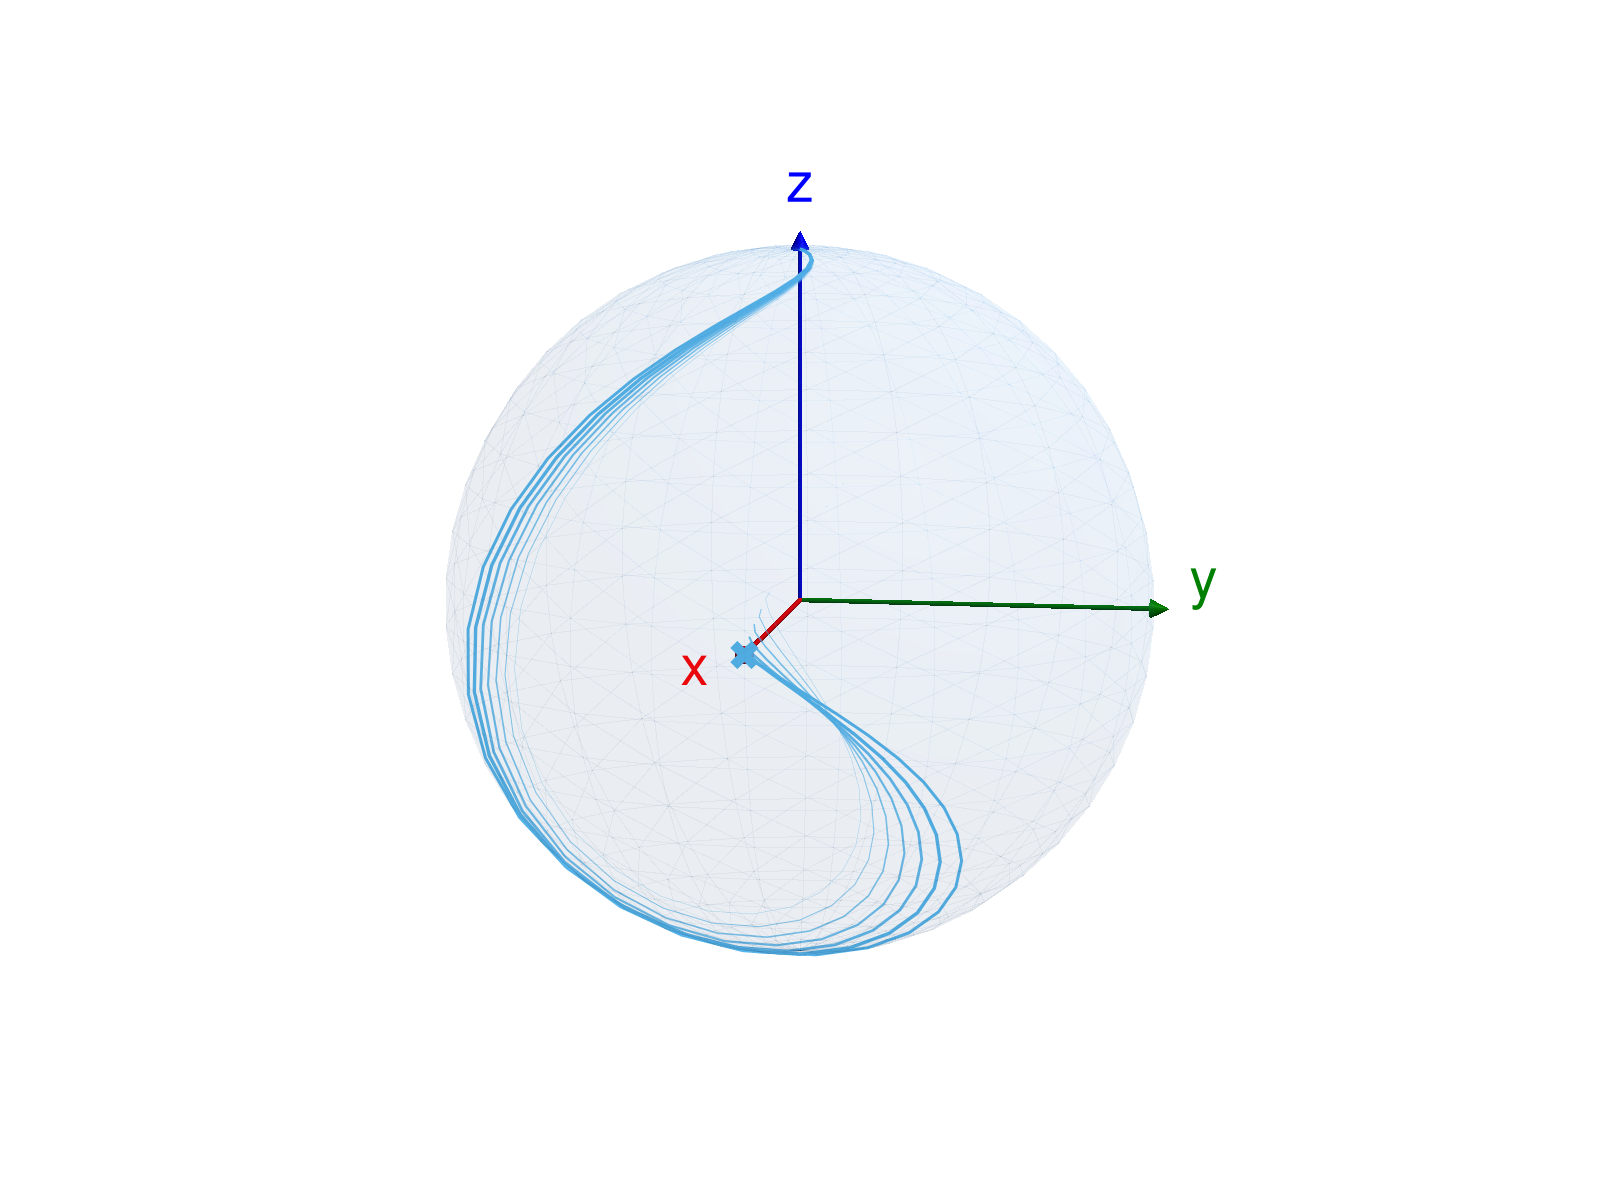

CairoMakie.Screen{IMAGE}


In [5]:
# Make plot
f  = CairoMakie.Figure(resolution = (800, 600), figure_padding=0)
ax = CairoMakie.Axis3(f[1, 1];
    aspect = :equal,
    xspinesvisible = false,
    yspinesvisible = false,
    zspinesvisible = false,
    xgridvisible  = false,
    ygridvisible  = false,
    zgridvisible  = false,
    xypanelvisible = false,
    xzpanelvisible = false,
    yzpanelvisible = false,
)

palette = to_colormap(:tab10)
styles  = (:solid, :dash, :dot, :dashdot)

origins = [Point3f(0,0,0), Point3f(0,0,0), Point3f(0,0,0)]
dirs    = [Vec3f(1.0,0,0), Vec3f(0,1.0,0), Vec3f(0,0,1.0)]

CairoMakie.arrows!(ax, origins, dirs;
    color = [:red, :green, :blue],
    arrowsize = 0.05,
    linewidth = 0.01
)

CairoMakie.text!(ax, "x", position = Point3f(1.2, -0.15, 0), align = (:left, :center),  color = :red,   fontsize = 28)
CairoMakie.text!(ax, "y", position = Point3f(0, 1.15, 0), align = (:center, :bottom), color = :green, fontsize = 28)
CairoMakie.text!(ax, "z", position = Point3f(0, 0, 1.1), align = (:center, :bottom), color = :blue,  fontsize = 28)

# Plot original trajectories
CairoMakie.lines!(ax, real.(expect_val_x), real.(expect_val_y), real.(expect_val_z);
    color     = colors[5],
    linestyle = styles[1],
    label     = latexstring("|0⟩ \\text{ to } |+⟩, \\; \\mathcal{E}"),
    linewidth = 1.5
)


# Plot perturbed trajectories with fading colors
for (i, (var_exp_x, var_exp_y, var_exp_z, eps)) in enumerate(var_perturbed_trajectories)
    # Calculate alpha (transparency) based on epsilon value
    # Higher epsilon = more transparent (fainter)
    alpha = 1.0 - (i-1) / (length(epsilons) + 1)  # Fade from 1.0 to ~0.25
    
    # Use a different color from the palette and adjust with RGBA
    color_with_alpha = (colors[5], alpha)
    
    CairoMakie.lines!(ax, real.(var_exp_x), real.(var_exp_y), real.(var_exp_z);
        color     = color_with_alpha,
        linestyle = styles[1],
        # label     = "Perturbed ε=$(eps)",
        linewidth = 2.0 - 0.3*i  # Also make lines thinner as epsilon increases
    )
    
    # Add endpoint markers for perturbed trajectories
    CairoMakie.scatter!(ax, [real(var_exp_x[end])], [real(var_exp_y[end])], [real(var_exp_z[end])];
        color = color_with_alpha, 
        markersize = 2.0 - 0.3*i,  # Smaller markers for higher epsilon
        marker = :diamond
    )
end

# Original endpoint markers
CairoMakie.scatter!(ax, [real(expect_val_x[end])], [real(expect_val_y[end])], [real(expect_val_z[end])];
    color = colors[5], markersize = 20, marker = :xcross)

CairoMakie.mesh!(ax, Sphere(Point3f(0,0,0), 1f0);
    color = (0.2, 0.6, 1.0, 0.05),
    transparency = true,
    shading = true
)

CairoMakie.xlims!(ax, -1.3, 1.3)
CairoMakie.ylims!(ax, -1.3, 1.3)
CairoMakie.zlims!(ax, -1.3, 1.3)

ax.azimuth[]   =  π/20
ax.elevation[] =  π/20

#CairoMakie.axislegend(ax; position = :lt)
CairoMakie.hidexdecorations!(ax, grid = false)
CairoMakie.hideydecorations!(ax, grid = false)
CairoMakie.hidezdecorations!(ax, grid = false)

f

base_path = "./artifacts/plots"
new_folder_name = "main_fig_plots" # <-- This is the new folder I named
filename = "rob_bloch.png" # You can use .png, .pdf, or .svg

# Create the full directory path
save_directory = joinpath(base_path, new_folder_name)

# Create the directory (and any intermediate paths) if it doesn't exist
# mkpath! doesn't error if the folder already exists
mkpath(save_directory)

# Define the full path for the file
full_save_path = joinpath(save_directory, filename)

# Save the figure
# This replaces the old last line ("fig")
# It will save the file and also display the fig in a notebook/REPL
save(full_save_path, f, px_per_unit = 10)
display(f)

In [6]:
# # Create the directory
# artifacts_dir = "artifacts/rob_bloch_data"
# mkpath(artifacts_dir)

# # Save htog_probs data for each seed in separate files
# for (i, seed) in enumerate(seeds)
#     save(joinpath(artifacts_dir, "rob_prob.jld2"), Dict(
#         "probs" => prob,
#         "seed" => seed,
#         "Qs" => Qs,
#         "F" => F,
#         "num_iter" => num_iter,
#         "hess_iter" => hess_iter,
#         "a_bound" => a_bound,
#         "dda_bound" => dda_bound,
#         "R" => R
#     ))
# end

# # Save the figure
# save(joinpath(artifacts_dir, "plot.png"), fig)

# println("Data saved to $artifacts_dir")
# println("Created $(length(seeds)) separate files, one for each seed")

## Functions

In [7]:
function var_obj(
    traj::NamedTrajectory, 
    H_drives::Vector{Matrix{ComplexF64}}, 
    H_errors::Vector{Matrix{ComplexF64}}
)
    Δt = traj.Δt[1]
    T = traj.T
    varsys = VariationalQuantumSystem(H_drives, H_errors)
    Ũ⃗, ∂Ũ⃗ = variational_unitary_rollout(traj, varsys)

    U = iso_vec_to_operator(Ũ⃗[:, end])
    # First error term
    ∂U = iso_vec_to_operator(∂Ũ⃗[1][:, end])

    d = size(U, 1)
    return abs(tr((U'*∂U)'*(U'*∂U))) / (T * Δt)^2 / d
end

function tog_obj(
    traj::NamedTrajectory, 
    H_drives::Vector{Matrix{ComplexF64}},
    H_error::Matrix{ComplexF64}
)
    T = traj.T
    Δt = get_timesteps(traj)

    sys = QuantumSystem(H_drives)
    U = iso_vec_to_operator.(eachcol(unitary_rollout(traj, sys)))
    
    # Toggle integral
    H_ti = sum(Δt[i] .* U[i]' * H_error * U[i] for i=1:T-1)

    d₁ = size(U[1], 1)
    Δt₁ = Δt[1]
    metric = norm(tr(H_ti'H_ti)) / (T * Δt₁)^2 / d₁
    return metric
end

function commutator(A::AbstractMatrix{<:Number}, B::AbstractMatrix{<:Number})
    return A*B - B*A
end

function pert_tog_obj(
    traj::NamedTrajectory, 
    H_drives::Vector{Matrix{ComplexF64}},
    H_error::Matrix{ComplexF64};
    order::Int=1,
    a_bound::Float64=a_bound
)
    T = traj.T
    Δt = get_timesteps(traj)

    sys = QuantumSystem(H_drives)
    U = iso_vec_to_operator.(eachcol(unitary_rollout(traj, sys)))

    # toggle integral
    H_ti = zeros(ComplexF64, size(U[1]))

    # note: U_1 = I, so U[:, k] = U_{k-1}.
    # you need to go to T-1, only
    for k in 1:T-1
        Hₖ = sum(traj.a[l, k] / a_bound * H for (l, H) in enumerate(H_drives))
        adjⁿH_E = H_error
        Eₖ_n = H_error * Δt[k]
        
        # get the different orders of the Hadamard lemma
        for n in 2:order
            coef_n = ComplexF64(im^(n-1) * a_bound^(n-1) * Δt[k]^n / factorial(big(n)))
            adjⁿH_E = commutator(Hₖ, adjⁿH_E)
            # Eₖ_n = push!(Eₖ_n, coef_n * adjⁿH_E)
            Eₖ_n += coef_n * adjⁿH_E
        end

        # nth order toggle integral up to k
        H_ti += U[k]' * Eₖ_n * U[k]
    end

    d₁ = size(U[1], 1)
    Δt₁ = Δt[1]
    metric = norm(tr(H_ti'H_ti)) / (T * Δt₁)^2 / d₁
    return metric
end

pert_tog_obj (generic function with 1 method)

In [8]:
"""
    upsample_constant(vals, dts; factor=2)

Take control values `vals` with time steps `dts` (same length),
and upsample by `factor`, returning (vals_up, dts_up).
"""
function upsample_constant_controls(vals::AbstractArray; factor::Int=2)
    vals_up = repeat(vals, inner=factor)
    return vals_up
end

function upsample_matrix(controls::AbstractArray, dts::AbstractArray; factor::Int=2)
    new_controls = []
    for c in eachrow(controls)
        new_c = upsample_constant_controls(c; factor=factor)
        push!(new_controls, new_c)
    end
    T = length(controls[1,:])
    dts_up = dts[1] / factor .* ones(length(dts) * factor * T)
    new_controls = reduce(vcat, [v' for v in new_controls])
    return new_controls, dts_up
end

function tog_obj_upsample(
    traj::NamedTrajectory, 
    H_drives::Vector{Matrix{ComplexF64}},
    H_error::Matrix{ComplexF64};
    factor::Int=1
)
    T = traj.T * factor
    controls = traj.a
    a_new, Δt_new = upsample_matrix(traj.a, traj.Δt; factor=factor)

    sys = QuantumSystem(H_drives)
    U = iso_vec_to_operator.(eachcol(unitary_rollout(a_new, Δt_new, sys)))
    
    # Toggle integral (truncate at (traj.T - 1) * factor)
    H_ti = sum(Δt_new[i] .* U[i]' * H_error * U[i] for i = 1:(traj.T - 1) * factor)

    d₁ = size(U[1], 1)
    Δt₁ = Δt_new[1]
    metric = norm(tr(H_ti'H_ti)) / (T * Δt₁)^2 / d₁
    return metric
end

tog_obj_upsample (generic function with 1 method)

In [9]:
var_traj = var_prob.trajectory
H_error = GATES.Z

2×2 Matrix{ComplexF64}:
 1.0+0.0im   0.0+0.0im
 0.0+0.0im  -1.0+0.0im

In [10]:
epsilon = tog_obj_upsample(var_traj, H_drive, H_error; factor=2^16)

1.5138629602748534e-9

In [11]:
var_epsilon = var_obj(var_traj, H_drive, [H_error])

1.5112519145827503e-9

In [12]:
pert_lst = []
for j in 1:5
    println(pert_tog_obj(var_traj, H_drive, H_error; order=j, a_bound=a_bound))
    push!(pert_lst, pert_tog_obj(var_traj, H_drive, H_error; order=j, a_bound=a_bound))
end

0.0003141609368955974
4.73245482032524e-6
8.90326492977552e-9
1.2141204390918695e-9
1.5119979602169911e-9


In [13]:
push!(pert_lst, var_epsilon)

6-element Vector{Any}:
 0.0003141609368955974
 4.73245482032524e-6
 8.90326492977552e-9
 1.2141204390918695e-9
 1.5119979602169911e-9
 1.5112519145827503e-9

In [14]:
using MathTeXEngine

latex_serif_theme = Theme(
    fontsize = 40,
    fonts = (; 
        regular = texfont(:text), 
        bold = texfont(:bold), 
        italic = texfont(:italic), 
        bold_italic = texfont(:bolditalic),
        ticks = "TeX Gyre Heros Makie"
    ),
    Axis = (; 
        xticklabelsize=30,
        yticklabelsize=30,
        xgridvisible=false
    )
)

set_theme!(latex_serif_theme)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /home/atkamen/.julia/packages/Makie/FUAHr/src/scenes.jl:238


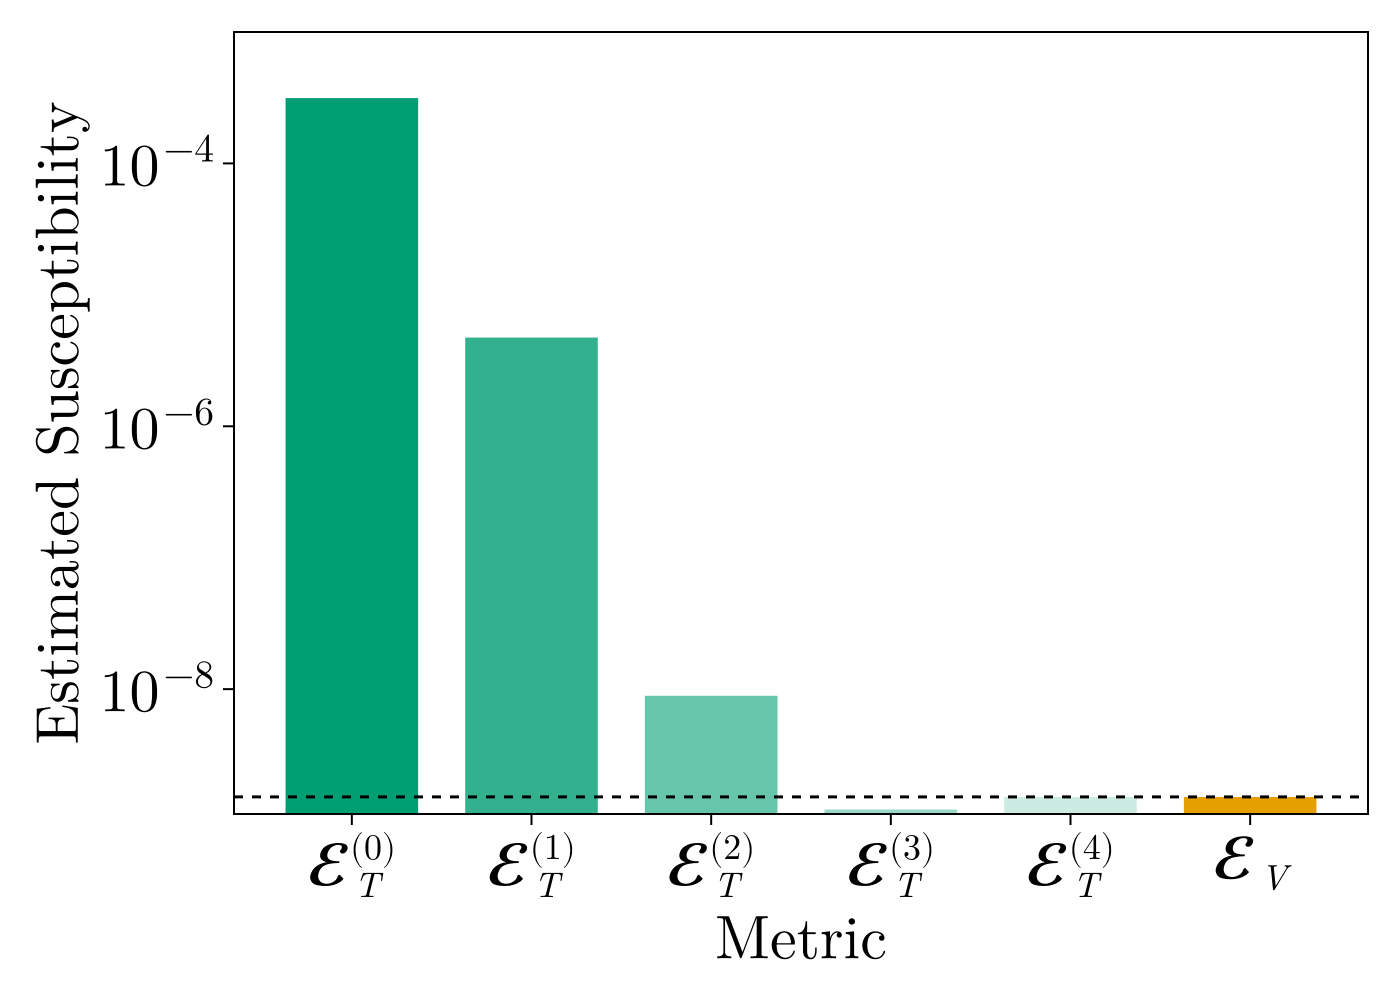

In [15]:
using CairoMakie
using Makie 
using ColorTypes: RGBA

values = pert_lst
labels = [L"\mathcal{E}_T^{(0)}", L"\mathcal{E}_T^{(1)}", L"\mathcal{E}_T^{(2)}",
          L"\mathcal{E}_T^{(3)}", L"\mathcal{E}_T^{(4)}", L"\mathcal{E}_V"]

f = CairoMakie.Figure(resolution = (700, 500), fontsize = 30)
ax = CairoMakie.Axis(f[1, 1];
    xlabel = "Metric",
    yscale = log10,
    ylabel = "Estimated Susceptibility",
)

# turn off grid
ax.xgridvisible[] = false
ax.ygridvisible[] = false

# Wong colors
wong = Makie.wong_colors()
base = wong[3]
colors = [
    wong[3],
    RGBA(base, 0.8),
    RGBA(base, 0.6),
    RGBA(base, 0.4),
    RGBA(base, 0.2),
    wong[2],
]

CairoMakie.barplot!(ax, 1:6, values;
    gap   = 0.18,
    width = 0.9,
    color = colors,
)

CairoMakie.hlines!(ax, epsilon; color = :black, linestyle = :dash, linewidth = 1.5, label = L"\mathcal{E}")
ax.xticks = (1:6, labels)

# CairoMakie.axislegend(ax; position = :rt, framevisible = true)
CairoMakie.hlines!(ax, 0, color = (:black, 0.3))
CairoMakie.ylims!(ax, 10^(-8.95), 1e-3)

save("./artifacts/plots/main_fig_plots/metric_comparison.svg", f, px_per_unit = 2)

f

In [16]:
Pkg.add("Makie")

   Resolving package versions...
  No Changes to `~/notebooks/src/Project.toml`
  No Changes to `~/notebooks/src/Manifest.toml`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651


In [17]:
Pkg.add("ColorTypes")

   Resolving package versions...
  No Changes to `~/notebooks/src/Project.toml`
  No Changes to `~/notebooks/src/Manifest.toml`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651
